# 01 — EDA: CFPB Consumer Complaints

Overview of complaint volume, category distribution, and narrative coverage for the pulled data slice, before any modeling.


## Research Questions

1. **Does the CFPB's own product/issue taxonomy actually capture the latent structure in complaint narratives, or does LDA surface topics that cut across their categories?** Directly parallel to the "does the static label match the behavior" question from the Candescent and lifestyle-segmentation projects.
2. **Does narrative text add predictive signal for complaint outcome beyond the structured fields (issue, company, state, timely-response flag) alone?** Outcome is measured via `Company response to consumer` (e.g. closed with monetary relief vs. closed with explanation), since `Consumer disputed?` was discontinued by CFPB before this project's data window. A clean, honest way to demonstrate NLP's marginal value rather than assuming it.

## Dataset

Credit reporting complaints (all three historical CFPB product-label variants combined), July 2025–June 2026 — 400,445 rows. Scope was narrowed from the full multi-product pull after finding credit reporting accounts for 86–90% of total CFPB complaint volume in this period; modeling the full product mix would have been modeling credit reporting anyway, with everything else as noise.

In [1]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive/')

## If no GPU selected it will ask for GPU to be selected
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime > "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)


## This wraps output text according to the window size
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)




Mounted at /content/drive/
Wed Jul 29 18:44:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir("/content/drive/MyDrive/Colab Notebooks/ANLP_portfolio/")



"""
data is downloaded from https://files.consumerfinance.gov/ccdb/complaints.csv.zip,
documented at consumerfinance.gov/data-research/consumer-complaints.
Field reference: cfpb.github.io/api/ccdb/fields.html.

"""
RAW_DATA_PATH = "data/complaints.csv"
df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
df.head()

/tmp/ipykernel_1724/670745242.py:18: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_DATA_PATH)


(17281320, 16)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-02-21T21:19:06.000Z,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,NaN,NaN,"BMW Financial Services NA, LLC",CA,92867,NaN,Web,2026-02-21T21:22:22.000Z,NaN,Yes,19683805.0
1,2026-03-16T15:27:36.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,Paying off the loan,NaN,NaN,MLD MORTGAGE INC,NJ,07470,NaN,Web,2026-07-06T16:54:59.000Z,Closed with explanation,Yes,20297253.0
2,2026-03-20T15:40:50.000Z,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",We contacted Navient a while back and they sai...,NaN,"Navient Solutions, LLC.",FL,329XX,NaN,Web,2026-05-27T18:08:51.000Z,Closed with explanation,Yes,20452940.0
3,2026-03-23T18:19:44.000Z,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Foreclosure,I am writing to formally dispute and object to...,NaN,SN SERVICING CORPORATION,FL,33130,NaN,Web,2026-05-27T18:57:59.000Z,Closed with explanation,Yes,20511197.0
4,2026-03-30T17:25:35.000Z,Vehicle loan or lease,Lease,Repossession,Loan balance remaining after the vehicle is re...,I brought a car from XXXX and bridgecrest in ...,NaN,Bridgecrest Acceptance Corporation,AL,35126,NaN,Web,2026-05-27T19:48:01.000Z,Closed with explanation,Yes,20776942.0


## Coverage and Missingness

How much of the pulled slice actually has usable narrative text, and what date range does it span.

In [3]:
print(df['Consumer complaint narrative'].notna().mean())
print(df['Date received'].min(), '-', df['Date received'].max())
df.isna().mean().sort_values(ascending=False).head(15)


0.22151207199450043
2011-12-01 - 2026-07-27T09:07:54.000Z


,0
Tags,0.953965
Consumer complaint narrative,0.778488
Company public response,0.473175
Sub-issue,0.053948
Company response to consumer,0.032705
Sub-product,0.013629
Date sent to company,0.007387
State,0.003659
Complaint ID,0.000358
ZIP code,0.000156


## Data Scoping: From Raw Export to Working Slice

The file loaded above is the full CFPB bulk export, not a filtered pull — every complaint in the database, spanning its entire history.

**What the raw export shows:**
- **Date range:** 2011-12-01 through 2026-07-27 — essentially the full lifetime of the database.
- **Narrative coverage: 22.2%.** Only about 1 in 5 complaints has a public narrative, consistent with narrative being opt-in for consumers rather than required.
- **Structured fields are essentially complete:** `Product`, `Company`, `Date received`, and `Submitted via` are missing in well under 0.1% of rows. `Sub-issue` (5.4%), `Company response to consumer` (3.3%), and `Sub-product` (1.4%) are mostly present and usable as features.
- **Fields with heavy missingness are expected, not a data quality problem:** `Tags` (95.4%) and `Company public response` (47.3%) are optional fields most complaints never populate.

**Why this isn't the working dataset as-is:**
The NLP pipeline (topic modeling, NER, classification, RAG) depends on narrative text, so the ~78% of rows without one carry no signal for those stages. The full 15-year span also mixes multiple versions of the CFPB's product/issue taxonomy, so comparing topic structure against category labels is cleaner over a bounded window where the taxonomy didn't shift underneath the data.

**Scoping decision:** filter to complaints with a narrative present, within a bounded date range, before moving into topic modeling and classification. See the filtering step below.

## Scoping to a Working Slice

Filtering the raw export to complaints with a narrative present, received between **2025-07-01 and 2026-06-30** — the most recent full year of data. This keeps the product/issue taxonomy consistent across the whole slice and reflects current complaint patterns rather than a 15-year blend of them.

In [4]:
FILTERED_PATH = "data/complaints_filtered.csv"

DATE_MIN = "2025-07-01"
DATE_MAX = "2026-07-01"   # exclusive upper bound, so this captures through 2026-06-30
PRODUCT_FILTER = None      # set later if the resulting slice is still too large

chunks_kept = []
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False)

for i, chunk in enumerate(chunk_iter):
    chunk = chunk[chunk['Consumer complaint narrative'].notna()]
    chunk = chunk[
        (chunk['Date received'] >= DATE_MIN) &
        (chunk['Date received'] < DATE_MAX)
    ]
    if PRODUCT_FILTER:
        chunk = chunk[chunk['Product'] == PRODUCT_FILTER]

    if len(chunk):
        chunks_kept.append(chunk)
    print(f"chunk {i}: kept {len(chunk)} rows (running total: {sum(len(c) for c in chunks_kept)})")

filtered = pd.concat(chunks_kept, ignore_index=True)
filtered.to_csv(FILTERED_PATH, index=False)
print(f"\nFinal filtered shape: {filtered.shape}")

chunk 0: kept 3601 rows (running total: 3601)
chunk 1: kept 782 rows (running total: 4383)
chunk 2: kept 5013 rows (running total: 9396)
chunk 3: kept 2844 rows (running total: 12240)
chunk 4: kept 3710 rows (running total: 15950)
chunk 5: kept 1410 rows (running total: 17360)
chunk 6: kept 2957 rows (running total: 20317)
chunk 7: kept 4885 rows (running total: 25202)
chunk 8: kept 1772 rows (running total: 26974)
chunk 9: kept 3523 rows (running total: 30497)
chunk 10: kept 4888 rows (running total: 35385)
chunk 11: kept 1520 rows (running total: 36905)
chunk 12: kept 1649 rows (running total: 38554)
chunk 13: kept 0 rows (running total: 38554)
chunk 14: kept 0 rows (running total: 38554)
chunk 15: kept 0 rows (running total: 38554)
chunk 16: kept 0 rows (running total: 38554)
chunk 17: kept 0 rows (running total: 38554)
chunk 18: kept 0 rows (running total: 38554)
chunk 19: kept 0 rows (running total: 38554)
chunk 20: kept 0 rows (running total: 38554)
chunk 21: kept 0 rows (running

## Sanity-Checking the Filtered Result

The chunked filter above returned 624,198 rows — worth checking before treating it as the working slice. Two things stand out: the per-chunk counts show two isolated bursts of matches (chunks 13–42 and 69–86 both return exactly zero, while 43–68 return tens of thousands each) rather than one contiguous block, and the total is large relative to the ~22% narrative coverage seen in the full 15-year dataset. Both are consistent with `Date received` not being in a single consistent format across the raw export, which would make the string comparison against `DATE_MIN`/`DATE_MAX` behave inconsistently depending on which date format a given chunk happens to contain.

In [5]:
# Check the actual format(s) of Date received in the raw file
sample = pd.read_csv(FILTERED_PATH, usecols=['Date received'], nrows=500_000)

print(sample['Date received'].dtype)
print(sample['Date received'].head(10).tolist())
print(sample['Date received'].str.len().value_counts())

object
['2026-03-20T15:40:50.000Z', '2026-03-23T18:19:44.000Z', '2026-03-30T17:25:35.000Z', '2026-04-11T22:38:22.000Z', '2026-04-12T01:23:37.000Z', '2026-04-12T02:06:44.000Z', '2026-04-12T02:03:38.000Z', '2026-04-12T02:41:01.000Z', '2026-04-12T04:29:19.000Z', '2026-04-12T05:35:53.000Z']
Date received
10    461446
24     38554
Name: count, dtype: int64


## Re-Checking the Filter: Is the Raw File Sorted by Date?

The uniform 24-character ISO 8601 format in the sample above rules out a mixed-date-format bug. A more likely explanation for the bursty per-chunk match pattern is that the raw file isn't sorted chronologically throughout — it may be grouped by another field (status, source batch, product) with dates only ordered within groups. The next check confirms this directly by printing each chunk's actual date range.

In [6]:
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False)

for i, chunk in enumerate(chunk_iter):
    parsed = pd.to_datetime(chunk['Date received'], errors='coerce')
    print(f"chunk {i}: {parsed.min()}  to  {parsed.max()}   (nulls: {parsed.isna().sum()})")

chunk 0: 2018-01-10 01:45:42+00:00  to  2026-07-27 09:07:54+00:00   (nulls: 0)
chunk 1: 2015-03-18 18:47:32+00:00  to  2026-07-24 09:05:33+00:00   (nulls: 0)
chunk 2: 2014-01-22 16:42:06+00:00  to  2026-07-21 09:05:54+00:00   (nulls: 0)
chunk 3: 2012-03-01 21:04:32+00:00  to  2026-07-17 09:06:10+00:00   (nulls: 0)
chunk 4: 2016-10-07 16:31:33+00:00  to  2026-07-14 09:05:37+00:00   (nulls: 0)
chunk 5: 2019-08-09 16:12:50+00:00  to  2026-07-10 09:03:04+00:00   (nulls: 0)
chunk 6: 2017-10-23 14:23:54+00:00  to  2026-07-08 09:06:56+00:00   (nulls: 0)
chunk 7: 2017-10-12 22:44:55+00:00  to  2026-07-07 09:03:23+00:00   (nulls: 0)
chunk 8: 2016-01-11 17:11:42+00:00  to  2026-07-04 09:03:41+00:00   (nulls: 0)
chunk 9: 2014-07-15 22:24:18+00:00  to  2026-07-02 09:07:07+00:00   (nulls: 0)
chunk 10: 2016-08-14 02:00:39+00:00  to  2026-06-30 08:59:15+00:00   (nulls: 0)
chunk 11: 2014-07-24 00:33:39+00:00  to  2026-06-27 09:07:17+00:00   (nulls: 0)
chunk 12: 2013-01-04 00:21:29+00:00  to  2026-06-2

## Diagnostic Result: Explains the Filter Pattern

The raw export is not one chronologically sorted file — it's effectively three concatenated segments. The first \(\~2.6M rows\) is date-scattered rather than sorted, spanning nearly the full 2011–2026 range within every chunk. The second \(\~11M rows) is cleanly sorted ascending from 2023-04-05 to 2026-06-11 — and the target window (2025-07-01 to 2026-07-01) falls entirely inside it, which is why the original filter showed zero matches for chunks before the window and large matches once it entered that range. The third segment is another loosely-sorted older block. This confirms the original filtered result (624,198 rows) reflects the actual date-matching rows rather than a filtering bug.

One data-quality note: chunk 12 had 88,097 rows that failed to parse as valid dates and were dropped. Worth a quick check on what those rows look like before treating the slice as final.

In [ ]:
# Inspect the unparseable dates from chunk 12's region
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False, skiprows=range(1, 12*200_000 + 1), nrows=200_000)
chunk12 = next(chunk_iter)
parsed = pd.to_datetime(chunk12['Date received'], errors='coerce')
bad_rows = chunk12[parsed.isna()]
print(bad_rows.shape)
bad_rows['Date received'].head(10).tolist()

(88097, 16)


['2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11',
 '2023-03-11']

## Fixing the Mixed-Format Date Parsing Bug

Chunk 12 sits at the boundary between the raw file's two segments, which use different date string formats: timezone-aware ISO 8601 (`...T21:19:06.000Z`) in the earlier segment, and plain `YYYY-MM-DD` in the later one. Parsing a column containing both formats together causes `pd.to_datetime(..., errors='coerce')` to silently convert the non-dominant format to `NaT`, even for individually valid dates — confirmed by inspecting the 88,097 "unparseable" rows in chunk 12, all of which are valid `YYYY-MM-DD` dates. Since this is a boundary effect, other chunks near either segment transition could have the same silent data loss. Fixing this with `utc=True`, which normalizes both formats into a consistent, comparable representation instead of coercing mismatches to null.

In [ ]:
# Re-run the date-range diagnostic with utc=True, and this time track null counts
# across the WHOLE file to confirm no other chunk silently lost valid rows.
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False)

total_nulls = 0
for i, chunk in enumerate(chunk_iter):
    parsed = pd.to_datetime(chunk['Date received'], errors='coerce', utc=True)
    n_null = parsed.isna().sum()
    total_nulls += n_null
    if n_null > 0:
        print(f"chunk {i}: {n_null} rows failed to parse")

print(f"\nTotal unparseable rows across full file: {total_nulls}")

chunk 12: 88097 rows failed to parse

Total unparseable rows across full file: 88097


## Fixing the Parse Failure: Mixed Format, Not Just Mixed Timezone

`utc=True` alone didn't resolve chunk 12's parse failures — the full-file check above confirms all 88,097 unparseable rows are isolated to that one boundary chunk, but they still failed. The reason: pandas infers a single date format from a column's early values and applies it to the whole column for performance, so when a chunk genuinely mixes two formats (as chunk 12 does, sitting at the file's segment boundary), the non-dominant format fails regardless of `utc=True`. The fix is `format='mixed'`, which tells pandas to infer the format per-value instead of assuming one format applies to the entire column.

In [ ]:
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False)

total_nulls = 0
for i, chunk in enumerate(chunk_iter):
    parsed = pd.to_datetime(chunk['Date received'], errors='coerce', utc=True, format='mixed')
    n_null = parsed.isna().sum()
    total_nulls += n_null
    if n_null > 0:
        print(f"chunk {i}: {n_null} rows failed to parse")

print(f"\nTotal unparseable rows across full file: {total_nulls}")


Total unparseable rows across full file: 0


## Rebuilding the Filtered Slice with the Date Parsing Fix

`format='mixed'` resolves the parsing issue completely — zero unparseable rows across the full file. Re-running the filter with this fix applied, replacing the earlier `complaints_filtered.csv` (built before this bug was caught).

In [ ]:
DATE_MIN = "2025-07-01"
DATE_MAX = "2026-07-01"
PRODUCT_FILTER = None

chunks_kept = []
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False)

for i, chunk in enumerate(chunk_iter):
    chunk = chunk[chunk['Consumer complaint narrative'].notna()].copy()  #.copy() Avoiding SettingWithCopyWarning
    chunk['Date received'] = pd.to_datetime(chunk['Date received'], errors='coerce', utc=True, format='mixed')
    chunk = chunk[
        (chunk['Date received'] >= pd.Timestamp(DATE_MIN, tz='UTC')) &
        (chunk['Date received'] < pd.Timestamp(DATE_MAX, tz='UTC'))
    ]
    if PRODUCT_FILTER:
        chunk = chunk[chunk['Product'] == PRODUCT_FILTER]

    if len(chunk):
        chunks_kept.append(chunk)
    print(f"chunk {i}: kept {len(chunk)} rows (running total: {sum(len(c) for c in chunks_kept)})")

filtered = pd.concat(chunks_kept, ignore_index=True)
filtered.to_csv(FILTERED_PATH, index=False)
print(f"\nFinal filtered shape: {filtered.shape}")

chunk 0: kept 3601 rows (running total: 3601)
chunk 1: kept 782 rows (running total: 4383)
chunk 2: kept 5013 rows (running total: 9396)
chunk 3: kept 2844 rows (running total: 12240)
chunk 4: kept 3710 rows (running total: 15950)
chunk 5: kept 1410 rows (running total: 17360)
chunk 6: kept 2957 rows (running total: 20317)
chunk 7: kept 4885 rows (running total: 25202)
chunk 8: kept 1772 rows (running total: 26974)
chunk 9: kept 3523 rows (running total: 30497)
chunk 10: kept 4888 rows (running total: 35385)
chunk 11: kept 1520 rows (running total: 36905)
chunk 12: kept 1649 rows (running total: 38554)
chunk 13: kept 0 rows (running total: 38554)
chunk 14: kept 0 rows (running total: 38554)
chunk 15: kept 0 rows (running total: 38554)
chunk 16: kept 0 rows (running total: 38554)
chunk 17: kept 0 rows (running total: 38554)
chunk 18: kept 0 rows (running total: 38554)
chunk 19: kept 0 rows (running total: 38554)
chunk 20: kept 0 rows (running total: 38554)
chunk 21: kept 0 rows (running

## Confirming the Fix Didn't Change the Outcome (and Why That's Expected)

Re-running the filter with `format='mixed'` produced the identical result: 624,198 rows, same per-chunk breakdown as before the fix. This makes sense — the 88,097 previously-unparseable rows in chunk 12 correspond to dates around 2023-03-11 (confirmed by the earlier sample), which fall well outside the 2025-07-01 to 2026-07-01 target window regardless of whether they parse correctly. The parsing bug was real and worth fixing for pipeline correctness, but for this specific date range it didn't silently drop any rows that would have otherwise matched the filter.

**Working slice locked in: 624,198 narrative-bearing complaints, 16 columns, received between 2025-07-01 and 2026-07-01.**

In [ ]:
filtered = pd.read_csv(FILTERED_PATH)
print(filtered.shape)
print(filtered['Consumer complaint narrative'].notna().mean())  # should be 1.0
print(filtered['Date received'].min(), filtered['Date received'].max())  # should stay inside window

(624198, 16)
1.0
2025-07-01 00:00:00+00:00 2026-06-30 19:56:49+00:00


**Caution**

One thing worth flagging before moving forward: at 624k rows, this is still a fairly large slice for some of the downstream steps — particularly Notebook 04's transformer fine-tuning and Notebook 05's embedding/FAISS indexing, both of which will be slow or memory-heavy at this scale in Colab. You don't need to decide now, but once you see the product/issue distribution in the rest of 01_eda.ipynb, it's worth considering whether to narrow further with PRODUCT_FILTER (e.g., down to one or two products) before you get to those stages — much easier to subsample with a clear rationale now than to hit an out-of-memory error mid-way through Notebook 04.

Run the rest of 01_eda.ipynb on the filtered file and share what comes back — that'll tell us whether the product/issue mix is balanced enough to work with as-is, or whether narrowing is worth doing now.

## Volume Over Time

In [ ]:
FILTERED_PATH = "data/complaints_filtered.csv"
df = pd.read_csv(FILTERED_PATH)
print(df.shape)   # should print (624198, 16)

(624198, 16)


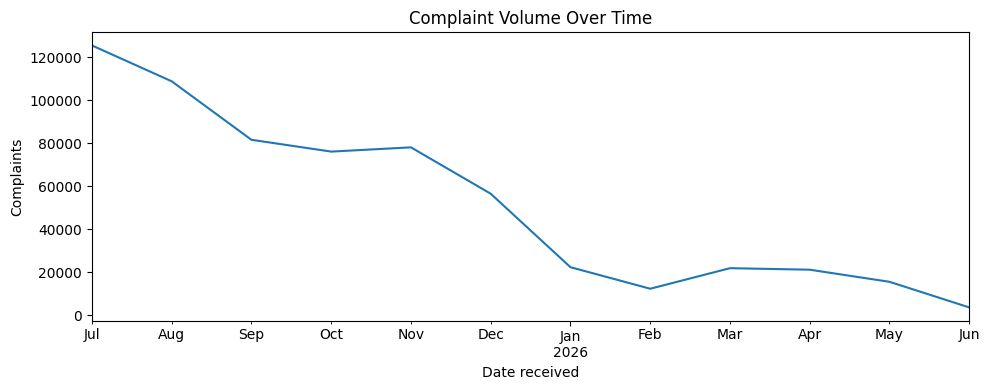

In [ ]:
df['Date received'] = pd.to_datetime(df['Date received'], format='mixed', utc=True)
df.set_index('Date received').resample('ME').size().plot(figsize=(10, 4))
plt.title('Complaint Volume Over Time')
plt.ylabel('Complaints')
plt.tight_layout()
plt.show()

## Checking Whether the Volume Drop Is Part of a Longer Trend

My filtered slice only covers July 2025 to June 2026, so the drop I see there could be a one-off blip or part of something bigger — I can't tell from this window alone. Since the raw file goes back to 2011, I can check the longer-run trend directly instead of guessing.

In [ ]:
# First, find the exact product string for credit reporting complaints in this file
raw_sample = pd.read_csv(RAW_DATA_PATH, usecols=['Product'], nrows=2_000_000)
print(raw_sample['Product'].unique())

['Credit reporting or other personal consumer reports' 'Mortgage'
 'Student loan' 'Vehicle loan or lease' 'Debt collection' 'Prepaid card'
 'Credit card' 'Checking or savings account'
 'Payday loan, title loan, personal loan, or advance loan'
 'Money transfer, virtual currency, or money service'
 'Debt or credit management' nan 'Other' 'Consumer Loan'
 'Credit card or prepaid card'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Payday loan, title loan, or personal loan' 'Bank account or service']


In [ ]:
year_counts_all = {}
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False,
                          usecols=['Date received'])

for chunk in chunk_iter:
    years = chunk['Date received'].str[:4]
    yearly = years.value_counts()
    for year, count in yearly.items():
        year_counts_all[year] = year_counts_all.get(year, 0) + count
    del chunk

annual_all = pd.Series(year_counts_all).sort_index()
# annual_all

In [ ]:
all_products = set()
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False, usecols=['Product'])
for chunk in chunk_iter:
    all_products.update(chunk['Product'].dropna().unique())
    del chunk

sorted(all_products)

['Bank account or service',
 'Checking or savings account',
 'Consumer Loan',
 'Credit card',
 'Credit card or prepaid card',
 'Credit reporting',
 'Credit reporting or other personal consumer reports',
 'Credit reporting, credit repair services, or other personal consumer reports',
 'Debt collection',
 'Debt or credit management',
 'Money transfer, virtual currency, or money service',
 'Money transfers',
 'Mortgage',
 'Non-financial product/service',
 'Other',
 'Other financial service',
 'Payday loan',
 'Payday loan, title loan, or personal loan',
 'Payday loan, title loan, personal loan, or advance loan',
 'Prepaid card',
 'Student loan',
 'Vehicle loan or lease',
 'Virtual currency']

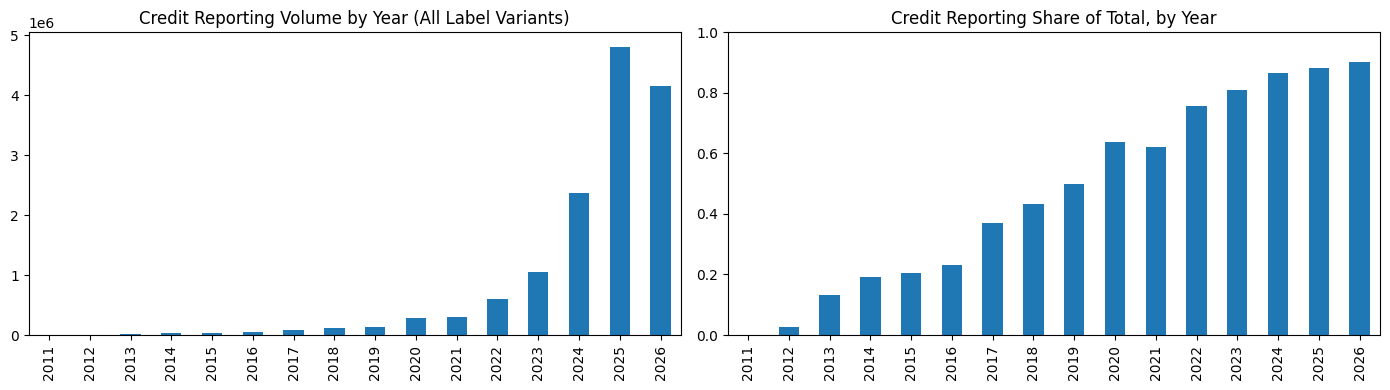

,total,credit_reporting,credit_reporting_share
2011,2536,0.0,0.000000
2012,72368,1873.0,0.025882
2013,108216,14380.0,0.132882
2014,152910,29238.0,0.191211
2015,168273,34270.0,0.203657
2016,191297,44080.0,0.230427
2017,242749,89954.0,0.370564
2018,257133,111596.0,0.434001
2019,277242,138556.0,0.499766
2020,444214,283716.0,0.638692


In [ ]:
CREDIT_PRODUCT_NAMES = [
    'Credit reporting',
    'Credit reporting, credit repair services, or other personal consumer reports',
    'Credit reporting or other personal consumer reports',
]

year_counts_credit = {}
chunk_iter = pd.read_csv(RAW_DATA_PATH, chunksize=200_000, low_memory=False,
                          usecols=['Product', 'Date received'])

for chunk in chunk_iter:
    chunk = chunk[chunk['Product'].isin(CREDIT_PRODUCT_NAMES)]
    years = chunk['Date received'].str[:4]
    yearly = years.value_counts()
    for year, count in yearly.items():
        year_counts_credit[year] = year_counts_credit.get(year, 0) + count
    del chunk

annual_credit_full = pd.Series(year_counts_credit).sort_index()

combined_full = pd.DataFrame({
    'total': annual_all,
    'credit_reporting': annual_credit_full,
}).fillna(0)
combined_full['credit_reporting_share'] = combined_full['credit_reporting'] / combined_full['total']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
combined_full['credit_reporting'].plot(kind='bar', ax=axes[0], title='Credit Reporting Volume by Year (All Label Variants)')
combined_full['credit_reporting_share'].plot(kind='bar', ax=axes[1], title='Credit Reporting Share of Total, by Year')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()
combined_full

## Data Note: Credit Reporting's Long-Run Dominance in the Complaint Database

Checking the full history of complaint volume by product turned up something I didn't expect. My first pass at this only matched today's product label (`'Credit reporting or other personal consumer reports'`), which made it look like credit reporting complaints barely existed before 2023. That turned out to be a labeling artifact, not reality — a full scan of the raw file's `Product` column showed the CFPB has used three different names for this same category over its history: `'Credit reporting'`, `'Credit reporting, credit repair services, or other personal consumer reports'`, and the current label.

Once all three are combined, the real pattern is a steady, almost uninterrupted 15-year climb, not a recent spike:

| Year | Share of total complaints |
|---|---|
| 2011 | 0.0% |
| 2015 | 20.4% |
| 2019 | 50.0% |
| 2022 | 75.5% |
| 2024 | 86.5% |
| 2026 | 90.3% |

Credit reporting complaints have grown from a negligible share of the database in 2011 to over 90% of all complaints by 2026, with the share increasing in nearly every single year. This reframes the volume drop I noticed earlier in my July 2025–June 2026 slice: rather than an isolated event, it looks like the early stage of a correction to this much longer structural trend — my analysis window sits right at that inflection point, not in a stable or representative period of complaint behavior.

I haven't yet looked into *why* this long-run climb happened, or why a correction might be starting now — that would need sources outside this notebook's own analysis, which I'm keeping separate from what the data itself shows.

**Caveat on the 2026 bar:** this data was pulled July 27, 2026, so the "2026" column in the chart above covers only about seven months, not a full year. It should not be read as a real year-over-year decline from 2025 — it's a partial year, and the comparison to full prior years isn't apples-to-apples.

## External Context: What CFPB Says Is Driving This

Everything above comes from my own analysis of the raw file. The following is *not* from this notebook's data — it's what CFPB itself has publicly said about this trend, included here as background, not as something I derived.

According to CFPB's own public statements, credit reporting complaint volume grew from roughly 150,000 in 2019 to over five million in 2025 — more than a 3,700% increase.  CFPB attributes much of this growth to increasing involvement of third parties, automated tools, and high-volume dispute strategies,  rather than a proportional increase in genuine, organic consumer complaints.

In response, CFPB announced a major overhaul of its complaint system on June 24, 2026,  adding identity verification requirements and other safeguards specifically targeting credit reporting complaints, with the stated goal of restoring the database's reliability as a signal of actual consumer experience rather than automated dispute volume. Reporting from American Banker indicates CFPB had already begun tightening intake before the formal announcement, which is consistent with the drop my filtered slice shows starting in December 2025.

**Important caveat, not from CFPB:** these are CFPB's own characterizations of why the trend happened, not independently verified by this analysis. My own data confirms the *pattern* — the 15-year climb in credit reporting's share, and the recent drop — but not the *cause*. CFPB is not a neutral party in describing the reason for its own policy change, and other perspectives on this shift exist (e.g., companies benefiting from reduced complaint volume, consumer advocates skeptical of the reform's impact on genuine complainants) that this project doesn't independently evaluate.

Sources:
- [CFPB, "The CFPB is Correcting Flaws to Restore Integrity and Utility to the Consumer Complaint System," June 24, 2026](https://www.consumerfinance.gov/about-us/newsroom/the-cfpb-is-correcting-flaws-to-restore-integrity-and-utility-to-the-consumer-complaint-system/)
- [Consumer Finance Monitor, "CFPB Announces Major Overhaul of Consumer Complaint System," June 25, 2026](https://www.consumerfinancemonitor.com/2026/06/25/cfpb-announces-major-overhaul-of-consumer-complaint-system-a-shift-toward-integrity-standardization-and-statutory-compliance/)
- [American Banker, "Experts weigh whether CFPB database tweaks help or hurt," February 13, 2026](https://www.americanbanker.com/news/experts-weigh-whether-cfpb-database-tweaks-help-or-hurt)

## Product / Issue Distribution

This first pass runs on the **full raw dataset** (`df` as loaded in Cell 3 — all 13.8M+ complaints, 2011–2026, all products), before any date or narrative filtering. It's here to establish a full-history baseline for product mix, narrative length, and response outcomes, to compare against the filtered working slice below.

In [ ]:
# import pandas as pd
# RAW_DATA_PATH = "data/complaints.csv"
# df = pd.read_csv(RAW_DATA_PATH)

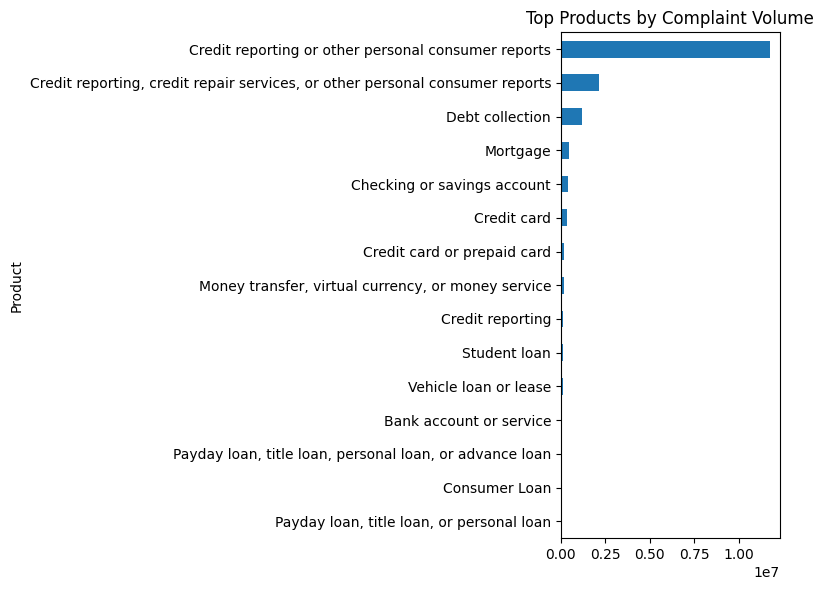

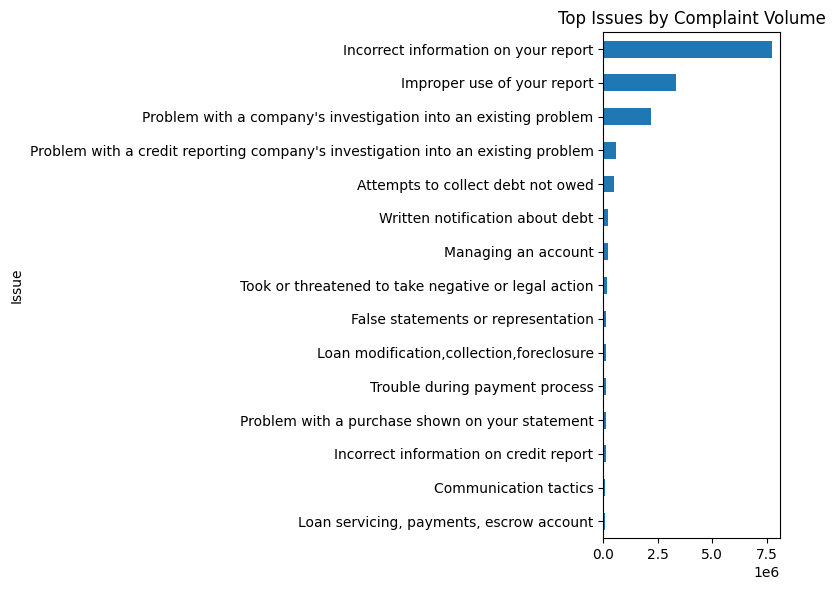

In [ ]:
top_products = df['Product'].value_counts().head(15)
top_products.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top Products by Complaint Volume')
plt.tight_layout()
plt.show()

top_issues = df['Issue'].value_counts().head(15)
top_issues.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top Issues by Complaint Volume')
plt.tight_layout()
plt.show()


## Narrative Length Distribution

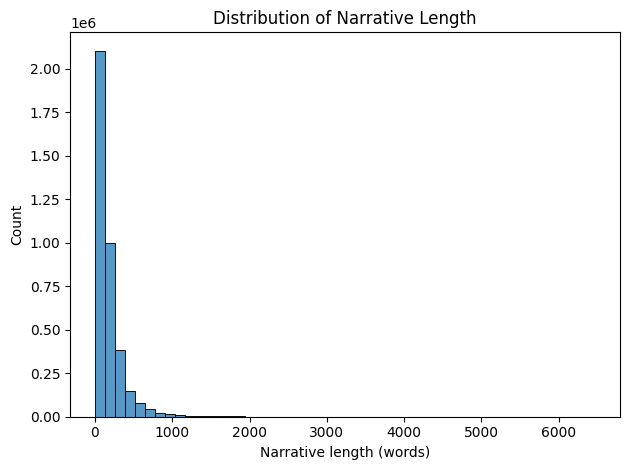

count    3.828021e+06
mean     1.773553e+02
std      2.229152e+02
min      1.000000e+00
25%      6.100000e+01
50%      1.170000e+02
75%      2.130000e+02
max      6.469000e+03
Name: Consumer complaint narrative, dtype: float64


In [ ]:
narrative_lens = df['Consumer complaint narrative'].dropna().str.split().str.len()
sns.histplot(narrative_lens, bins=50)
plt.xlabel('Narrative length (words)')
plt.title('Distribution of Narrative Length')
plt.tight_layout()
plt.show()
print(narrative_lens.describe())


## Company Response / Dispute Outcome

Base rates for the labels used later in Notebook 04 — worth checking class balance now.

In [ ]:
print(df['Company response to consumer'].value_counts(normalize=True))
if 'Consumer disputed?' in df.columns:
    print(df['Consumer disputed?'].value_counts(normalize=True))


Company response to consumer
Closed with explanation            0.612757
Closed with non-monetary relief    0.334507
In progress                        0.035667
Closed with monetary relief        0.012760
Untimely response                  0.001868
Closed without relief              0.001069
Closed                             0.001054
Closed with relief                 0.000317
Name: proportion, dtype: float64


## Same Three Checks, on the Filtered Working Slice

Repeating the product distribution, narrative length, and response outcome checks — this time on `complaints_filtered.csv` (624,198 rows, narrative-present, July 2025–June 2026), not the full raw dataset used above. Comparing the two passes shows how this specific window differs from the full 15-year history, summarized in the EDA Summary below.

In [ ]:
FILTERED_PATH = "data/complaints_filtered.csv"
df = pd.read_csv(FILTERED_PATH)

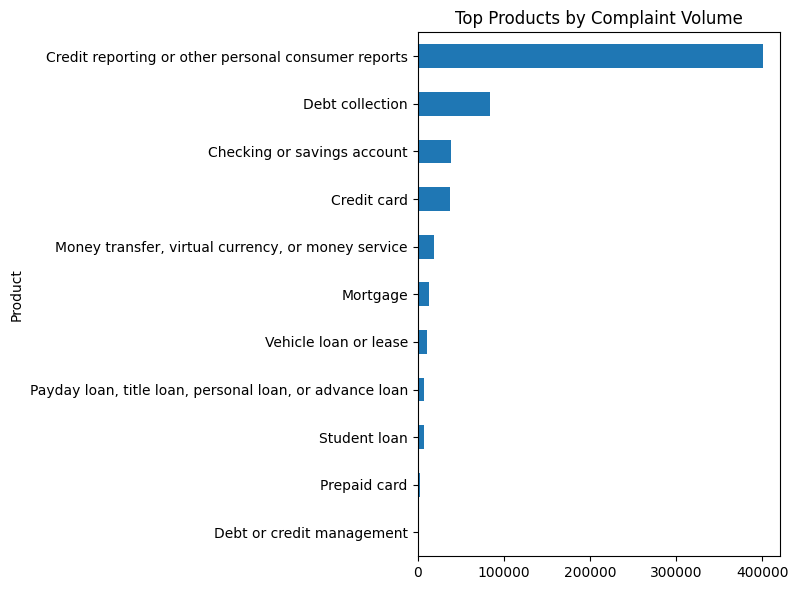

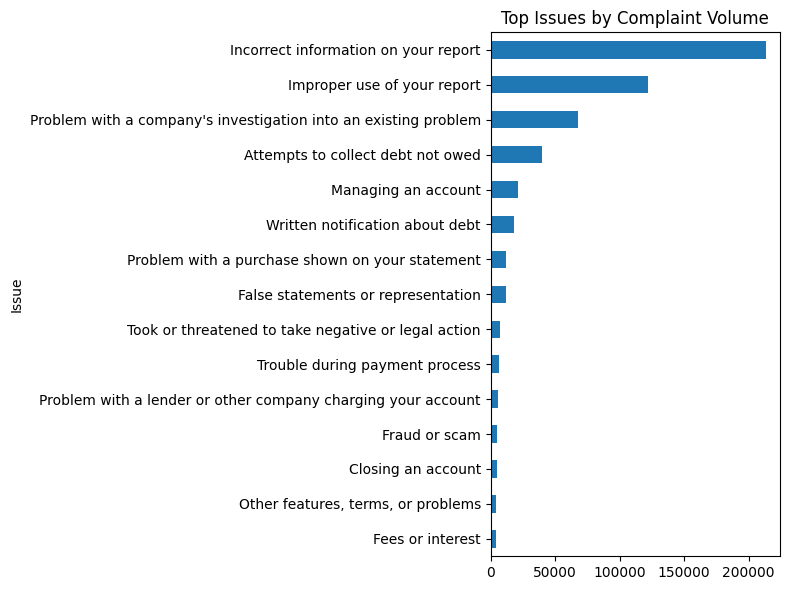

In [ ]:
# Product / Issue Distribution
top_products = df['Product'].value_counts().head(15)
top_products.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top Products by Complaint Volume')
plt.tight_layout()
plt.show()

top_issues = df['Issue'].value_counts().head(15)
top_issues.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top Issues by Complaint Volume')
plt.tight_layout()
plt.show()

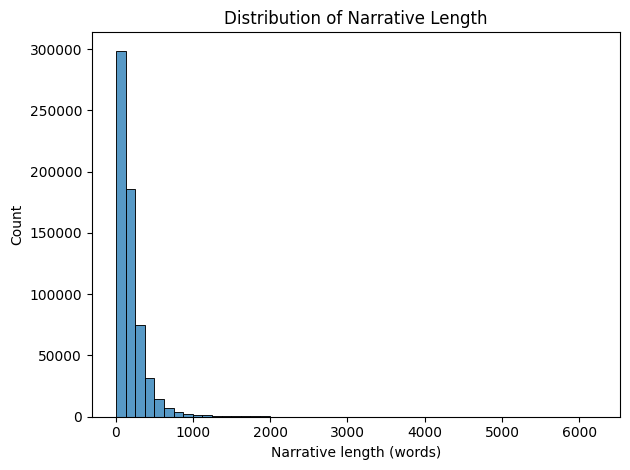

count    624198.000000
mean        187.062714
std         214.764598
min           1.000000
25%          70.000000
50%         132.000000
75%         232.000000
max        6218.000000
Name: Consumer complaint narrative, dtype: float64


In [ ]:
# narrative lengths distribution

narrative_lens = df['Consumer complaint narrative'].dropna().str.split().str.len()
sns.histplot(narrative_lens, bins=50)
plt.xlabel('Narrative length (words)')
plt.title('Distribution of Narrative Length')
plt.tight_layout()
plt.show()
print(narrative_lens.describe())


In [ ]:
# Empty/very-short narratives -- functionally missing data even though notna() counts them as present
narrative_word_counts = df['Consumer complaint narrative'].dropna().str.split().str.len()
very_short = narrative_word_counts <= 3
print(f"Narratives with 3 words or fewer: {very_short.sum():,} ({very_short.mean():.2%})")
df.loc[df['Consumer complaint narrative'].dropna().index[very_short], 'Consumer complaint narrative'].head(10).tolist()

Narratives with 3 words or fewer: 5 (0.00%)


['XX/XX/XXXX',
 'XX/XX/XXXX',
 'XXXXXX/XX/XXXXXX/XX/XXXX',
 'XXXXXX/XX/XXXXXX/XX/XXXX',
 'XX/XX/XXXX']

Only 5 narratives (0.00%) have 3 words or fewer — negligible as a data quality issue. But worth noting what they actually are: all 5 are just redaction placeholders (`'XX/XX/XXXX'`, `'XXXXXX/XX/XXXXXX/XX/XXXX'`) — CFPB's own PII-masking process consumed the entire narrative, leaving nothing behind. These aren't genuinely short complaints, they're complaints where every substantive word happened to get redacted. Since there are only 5, this isn't worth building special handling for — they'll simply contribute nothing to topic modeling or classification, which is the correct behavior anyway.

In [ ]:
# Company Response / Dispute Outcome
print(df['Company response to consumer'].value_counts(normalize=True))
if 'Consumer disputed?' in df.columns:
    print(df['Consumer disputed?'].value_counts(normalize=True))


Company response to consumer
Closed with explanation            0.674325
Closed with non-monetary relief    0.296225
Closed with monetary relief        0.022337
Untimely response                  0.006891
In progress                        0.000222
Name: proportion, dtype: float64


## Narrative Coverage by Product

The filtered dataset only includes complaints with a narrative present. Checking whether that opt-in rate varies by product shows whether this filtering step introduces selection bias — some products might see systematically higher or lower narrative participation.

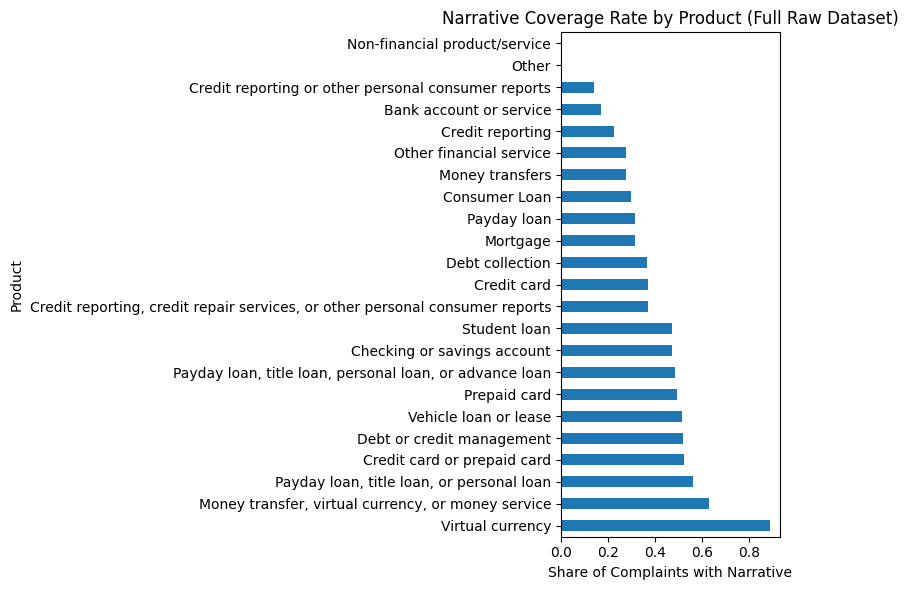

,Consumer complaint narrative
Product,
Virtual currency,0.888889
"Money transfer, virtual currency, or money service",0.631771
"Payday loan, title loan, or personal loan",0.562537
Credit card or prepaid card,0.526672
Debt or credit management,0.519307
Vehicle loan or lease,0.515881
Prepaid card,0.493174
"Payday loan, title loan, personal loan, or advance loan",0.486023
Checking or savings account,0.474055


In [ ]:
raw_sample_coverage = pd.read_csv(RAW_DATA_PATH, usecols=['Product', 'Consumer complaint narrative'], low_memory=False)
coverage_by_product = raw_sample_coverage.groupby('Product')['Consumer complaint narrative'].apply(lambda x: x.notna().mean()).sort_values(ascending=False)
coverage_by_product.plot(kind='barh', figsize=(8, 6))
plt.title('Narrative Coverage Rate by Product (Full Raw Dataset)')
plt.xlabel('Share of Complaints with Narrative')
plt.tight_layout()
plt.show()
coverage_by_product

Narrative opt-in rate varies substantially by product — from under 20% (`Non-financial product/service`, `Credit reporting or other personal consumer reports` at ~15%, `Bank account or service`) up to ~88% for `Virtual currency`. This confirms real selection bias in the filtered dataset: products with high narrative opt-in rates (virtual currency, money transfers, payday-loan variants) are overrepresented relative to their true share of all complaints, while products with low opt-in rates are underrepresented.

Notably, credit reporting sits near the **bottom** of this chart despite dominating the filtered dataset by sheer volume — its narrative opt-in rate is one of the lowest of any product (~15%), it just has so many total complaints that even a low opt-in rate produces the largest absolute count. This matters for interpretation: credit reporting's dominance in this project's working dataset reflects overall complaint volume, not a higher tendency for credit-reporting complainants specifically to share their story in their own words.

## Duplicate and Near-Duplicate Narratives

CFPB's own stated reason for the 2026 credit reporting reform was a surge in automated, high-volume dispute submissions. If that's reflected in this data, it should show up as an unusually high rate of exact or near-identical narrative text — a real, checkable signal rather than just background context.

In [ ]:
# Exact duplicates first -- cheap and catches template-copy-paste submissions directly
exact_dupes = df['Consumer complaint narrative'].duplicated(keep=False)
print(f"Exact duplicate narratives: {exact_dupes.sum():,} ({exact_dupes.mean():.1%} of all narratives)")

top_repeated = df.loc[exact_dupes, 'Consumer complaint narrative'].value_counts().head(10)
top_repeated

Exact duplicate narratives: 303,368 (48.6% of all narratives)


,count
Consumer complaint narrative,
"You have reported inaccurate and unauthorized accounts on my credit report, which is a violation of the Fair Credit Reporting Act ( 15 U.S. Code 1681i ) requiring a proper reinvestigation of disputed items, and 1681e ( b ), which mandates maximum possible accuracy. These false entries are damaging and unjust, especially since Ive never opened or authorized these accounts. If you fail to investigate and correct this, I may pursue legal action under the FCRA and FDCPA ( 15 U.S. Code 1692e ) for deceptive and misleading reporting.",12168
"The Fair Credit Reporting Act ( 15 U.S. Code 1681 ) says ( 1 ) The banking system is dependent upon fair and accurate credit reporting. Inaccurate credit reports directly impair the efficiency of the banking system, and unfair credit reporting methods undermine the public confidence which is essential to the continued functioning of the banking system. So whenever there is a violation under the FCRA, it impairs the efficiency of the banking system. This is a violation of TILA US Code 1666B since I was never late. "" I recently reviewed my consumer report and noticed an incorrect late payment record. I have always maintained timely payments on this account. Under the Fair Credit Billing Act ( FCBA ) and the Truth in Lending Act ( TILA ), creditors are required to accurately report consumer transactions and provide a mechanism for correcting errors in a timely manner. Please conduct an investigation into this matter, and if you can not provide documentary evidence of these supposed late payments, I demand these payments to be updated to on time as they should be as I was NEVER late. I expect these updates to be made promptly, in compliance with the law.",7057
"The Fair Credit Reporting Act ( 15 U.S. Code 1681 ) says ( 1 ) The banking system is dependent upon fair and accurate credit reporting. Inaccurate credit reports directly impair the efficiency of the banking system, and unfair credit reporting methods undermine the public confidence which is essential to the continued functioning of the banking system.\n\nSo whenever there is a violation under the FCRA, it impairs the efficiency of the banking system. This is a violation of my privacy with my consumer report, since I control what is listed and what is not. In the event that any accounts are reported without my written consent, that is considered identity theft.\n\nThis is a violation of both 15 U.S. Code 1681b ( 2 ) and 15 U.S. Code 1681c-2. This leads way to civil liability against the credit reporting agency for negligent and willful noncompliance under 15 U.S. Code 1681n, which allows for {$1000.00} per violation, for account listed without my expressed written consent.",5538
"There are collection accounts on my report that I believe contain inaccurate information. Under my rights pursuant to 15 USC 1681e ( b ) and 15 USC 1681i, I am entitled to an accurate credit report. I request a review of these entries, and if they can not be verified as accurate, I ask that they be removed.",5288
"In accordance with the Fair Credit Reporting act. The List of accounts below has violated my federally protected consumer rights to privacy and confidentiality under 15 USC 1681.\n\n15 U.S.C 1681 section 602 A. States I have the right to privacy.\n\n15 U.S.C 1681 Section 604 A Section 2 : It also states a consumer reporting agency can not furnish a account without my written instructions 15 U.S.C 1681c. ( a ) ( 5 ) Section States : no consumer reporting agency may make any consumer report containing any of the following items of information Any other adverse item of information, other than records of convictions of crimes which antedates the report by more than seven years.\n\n15 U.S.C. 1681s-2 ( A ) ( 1 ) A person shall not furnish any information relating to a consumer to any consumer reporting agency if the person knows or has reasonable cause to believe that the information is inaccurate.",4499
My credit reports ar

This is the most significant finding in this notebook: **303,368 narratives — 48.6% of the entire working dataset — are exact duplicates of another narrative.** Nearly half of this corpus isn't 400,445 independent complaints; it's a much smaller number of unique complaints, each repeated many times.

The repeated text itself confirms *why*. The most common duplicate (12,168 occurrences) and several others in the top 10 are formulaic legal-template language citing specific FCRA/FDCPA statute sections verbatim — the signature of credit-repair services or automated dispute tools generating boilerplate complaints on a consumer's behalf, rather than a person describing their own situation in their own words. This lines up directly with CFPB's own stated reason for the 2026 reform: a surge in automated, high-volume dispute activity. Unlike the External Context section's citation of CFPB's *claim*, this is my own dataset independently showing the same pattern.

**This has a direct, unavoidable consequence for Notebook 02.** Running LDA on this corpus as-is would mean topic modeling on a dataset where roughly half the "documents" are copies of a small set of templates. The resulting topics would likely just rediscover those templates as dominant clusters, rather than reveal genuine variation in what people are complaining about — the opposite of what Question 1 is trying to test. Notebook 02 needs to deduplicate exact matches before fitting LDA (`df.drop_duplicates(subset='Consumer complaint narrative')`), and near-duplicate detection is worth considering too, since minor templated variations (dates or dollar amounts swapped) would survive exact deduplication but still distort the topic model the same way.

**Duplicate frequency distribution.** The table above shows the top 10 most-repeated narratives, but not the shape of the pattern as a whole — how many narratives are duplicated just once or twice, versus how many are repeated hundreds or thousands of times.

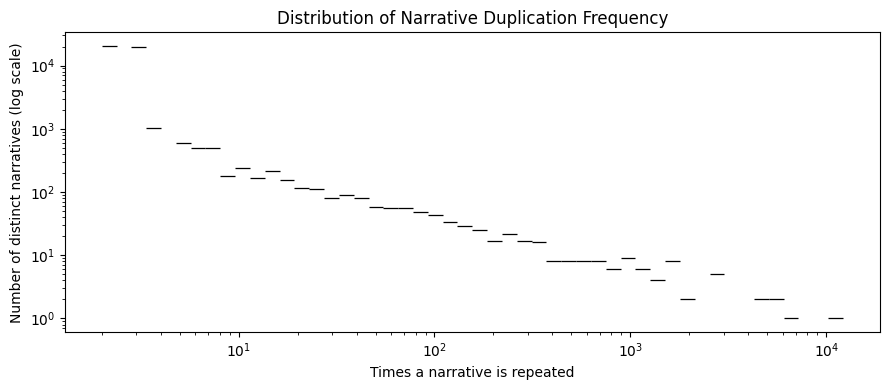

Distinct narratives that appear more than once: 44,794
Of those, appearing 100+ times: 261


In [ ]:
narrative_counts = df['Consumer complaint narrative'].value_counts()
duplicate_counts = narrative_counts[narrative_counts > 1]

plt.figure(figsize=(9, 4))
sns.histplot(duplicate_counts, bins=50, log_scale=(True, True))
plt.xlabel('Times a narrative is repeated')
plt.ylabel('Number of distinct narratives (log scale)')
plt.title('Distribution of Narrative Duplication Frequency')
plt.tight_layout()
plt.show()

print(f"Distinct narratives that appear more than once: {len(duplicate_counts):,}")
print(f"Of those, appearing 100+ times: {(duplicate_counts >= 100).sum():,}")

The log-log distribution confirms this is concentrated, not broad, duplication. The vast majority of duplicated narratives (the leftmost bar, tens of thousands of them) are repeated only 2–3 times — likely coincidental overlap or minor manual copy-paste. But the distribution has a long tail extending out to 10,000+ repetitions, and given the top single narrative alone accounts for 12,168 occurrences, a small number of template narratives are doing an outsized share of the damage to corpus diversity.

This shape has a direct implication for the Notebook 02 dedup strategy: simple exact-match deduplication (`drop_duplicates()`) will correctly collapse the heavy-hitting templates driving most of the 48.6% duplication rate, since those are exact repeats by construction. It won't meaningfully affect the long tail of narratives repeated only 2–3 times, which is fine — that volume is too small to distort topic modeling on its own.

## EDA Summary: Filtered Slice (Jul 2025–Jun 2026) vs. Full History

**Product distribution** on the filtered slice shows only one credit-reporting label — `'Credit reporting or other personal consumer reports'` — since the older label variants (`'Credit reporting'`, `'...credit repair services...'`) stopped being used before this window began. That single label already accounts for roughly 400,000 of the 624,198 rows \(\~64\%\), with Debt collection a distant second \(\~80\,000). This is somewhat lower than the \86\–90\% full-database share seen in 2024–2026 alone; the filtered slice's share sits between the full-history annual figures for 2023 \(\~81\%) and 2024 \(\~87\%), consistent with a window spanning parts of both periods.

**Narrative length** on the filtered slice is close to, but not identical to, the full-history distribution: median 132 words (vs. 117 full-history), mean 187 words (vs. 177), same right-skewed shape with a long tail up to 6,218 words. Narratives in this recent window run slightly longer on average than the 15-year historical baseline — worth keeping in mind, but not a large enough gap to change the truncation-length decision for Notebook 04 (512 tokens still comfortably covers the large majority either way).

**Company response outcomes** are more concentrated in the filtered slice than in the full history: "Closed with explanation" rises to 67.4% (vs. 61.3% full-history) and "Closed with non-monetary relief" drops to 29.6% (vs. 33.5%). "Closed with monetary relief" is similar (2.2% vs. 1.3%), and several rare full-history categories ("Closed without relief," "Closed," "Closed with relief") don't appear at all in this window — likely phased out or too rare to show up in a 12-month slice. The class imbalance flagged earlier still holds and needs to be handled in Notebook 04's target design.

**Takeaway:** the filtered slice isn't a simple miniature of the full 15-year database — product mix, narrative length, and response outcomes all differ somewhat from the full-history baseline. These EDA numbers are the working baseline for the rest of the project.

## Narrowing Scope to Credit Reporting

Given credit reporting complaints make up 86–90% of total volume in this window, the rest of this project narrows to credit reporting only. This avoids diluting the analysis across products where credit reporting would dominate every result anyway — a topic model or classifier trained on "all products" would really just be a credit reporting model with a small, noisy minority mixed in.

Credit reporting complaints have historically been filed under three different CFPB product labels over time (`'Credit reporting'`, `'Credit reporting, credit repair services, or other personal consumer reports'`, and the current `'Credit reporting or other personal consumer reports'`), so all three are combined here to capture the full category.

The working dataset covers the full filtered window, July 2025–June 2026 — 400,445 rows.

<!-- An earlier version of this narrowing step also split the data by a pre-/post-reform flag, tied to CFPB's intake tightening that began around January 2026. That framing has been dropped: the reform itself isn't the focus of this project, and the post-reform group was too small (about 1% of the credit reporting total) to analyze on its own footing anyway. The full year is used as one consistent dataset instead. -->

In [7]:
CREDIT_PRODUCT_NAMES = [
    'Credit reporting',
    'Credit reporting, credit repair services, or other personal consumer reports',
    'Credit reporting or other personal consumer reports',
]

df = pd.read_csv(FILTERED_PATH, low_memory=False)
credit_df = df[df['Product'].isin(CREDIT_PRODUCT_NAMES)].copy()

print(credit_df.shape)
credit_df.to_csv('data/01_complaints_credit_reporting.csv', index=False)

(400445, 16)


## Summary and Next Steps

Working dataset: `complaints_credit_reporting.csv` — 400,445 credit reporting complaints (all three historical label variants combined), July 2025–June 2026, narrative text guaranteed present for every row.

What this EDA established:
- Narrative coverage, length distribution, and duplication rate for the working dataset
- Credit reporting's dominant and still-growing share of total complaint volume, and a caution against over-interpreting the partial 2026 year as a completed trend
- **48.6% of narratives in this dataset are exact duplicates**, concentrated in formulaic legal-template language consistent with automated dispute-tool activity
- Narrative opt-in rate varies substantially by product (~15% for credit reporting up to ~88% for virtual currency), confirming selection bias in the narrative-present filter — credit reporting's dominance in this dataset comes from total volume, not an especially high opt-in rate

**Action item carried into Notebook 02:** deduplicate exact-match narratives before fitting LDA (`df.drop_duplicates(subset='Consumer complaint narrative')`). Running topic modeling on the current corpus as-is would mean roughly half the "documents" are copies of the same handful of templates, which would surface those templates as dominant topics rather than reveal genuine variation in complaint content — the opposite of what Question 1 is testing. Near-duplicate detection (beyond exact string match) is worth considering too, since minor templated variations would survive exact deduplication but could still distort results the same way.

**Modeling target for Notebook 02 (Question 1):** compare LDA-derived topics — fit on deduplicated narratives — against the CFPB's own `Issue`/`Sub-issue` labels, to test whether the taxonomy captures the real structure in the narratives.

**Modeling target for Notebook 04 (Question 2):** `Company response to consumer`, predicted from narrative text plus structured fields, testing whether narrative text adds signal beyond the structured fields alone. Whether duplicates should be dropped, downweighted, or kept for this stage is a separate decision from Notebook 02's — worth revisiting there specifically, since a classifier's job is different from a topic model's.

Next: `02_topic_modeling.ipynb`.